<a href="https://colab.research.google.com/github/eerdemYlmzz/sound_analysis/blob/main/genetic_algorithms_music_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

transformer architecture,not LSTM .

In [ ]:
import music21
#!pip install pretty_midi
import numpy as np
import math
import random

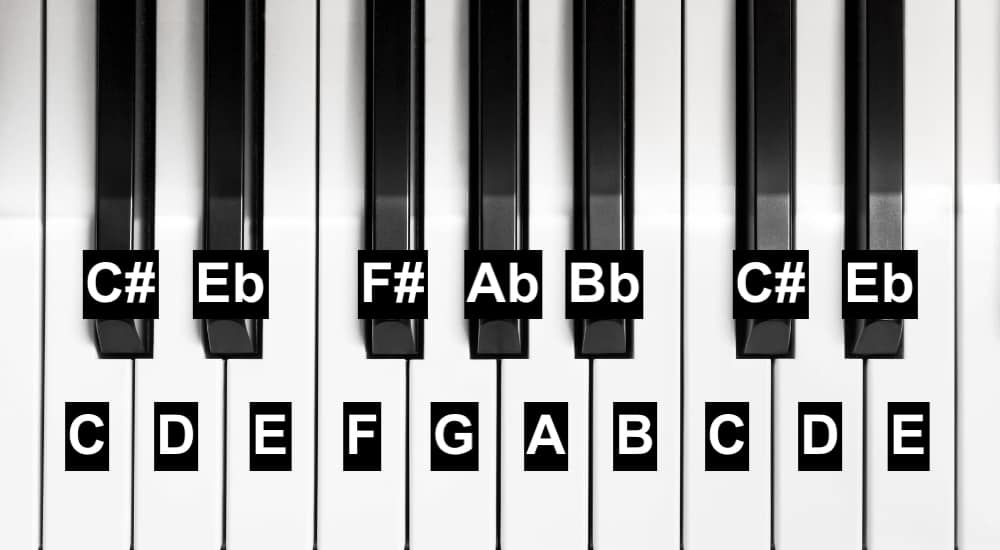

In [ ]:
#C="C D E F G A B"   ***** C major  + e --f  not +2  increase one by one ??  MIDI  0-127 . middle c= 60

In [ ]:
def build_pattern(root,pattern=[0,2,4,5,7,9,11]):
  return [root+i for i in pattern]

In [ ]:
build_pattern(60) # generic CMAJOR

[60, 62, 64, 65, 67, 69, 71]

In [ ]:
SCALES = {
    "C":build_pattern(60),
    "D":build_pattern(62),
    "E":build_pattern(64),
    "F":build_pattern(65),
    "G":build_pattern(67),
    "A":build_pattern(69),
    "B":build_pattern(71),
    "Am":  build_pattern(69, [0,2,3,5,7,8,10]),
    "Dm":  build_pattern(62, [0,2,3,5,7,8,10]),
    "Em":  build_pattern(64, [0,2,3,5,7,8,10]),

}
DURATIONS=[0.25,0.5,1.0,2.0] #16,8,4 2
CHROMOSOME_LENGTH=16


In [ ]:
def create_individuals(CHROMOSOME_LENGTH):
  chromosome=[]

  for i in range(CHROMOSOME_LENGTH):
    chromosome.append([random.choice(SCALES["C"]),random.choice(DURATIONS)])
  return chromosome


create_individuals(CHROMOSOME_LENGTH)




[[65, 0.25],
 [62, 1.0],
 [67, 0.5],
 [67, 1.0],
 [62, 0.25],
 [60, 2.0],
 [65, 2.0],
 [67, 2.0],
 [62, 0.5],
 [65, 0.25],
 [64, 0.5],
 [65, 1.0],
 [65, 1.0],
 [64, 0.25],
 [67, 2.0],
 [62, 0.25]]

In [ ]:
def create_population(n):
 return [create_individuals(CHROMOSOME_LENGTH) for _ in range(n)]


In [ ]:
create_population(1)

[[[65, 0.5],
  [67, 1.0],
  [65, 0.25],
  [65, 2.0],
  [69, 1.0],
  [60, 0.5],
  [69, 0.5],
  [64, 1.0],
  [60, 0.5],
  [69, 2.0],
  [64, 1.0],
  [67, 1.0],
  [64, 0.5],
  [60, 2.0],
  [62, 1.0],
  [60, 2.0]]]

In [ ]:

def interval_cost(individual):
  cost=0
  error=0
  for i in range(CHROMOSOME_LENGTH-1):
    cost= individual[i+1][0]-individual[i][0]
    if abs(cost) > 7:
      error+= abs(cost)


  return error


In [ ]:
#fitness function.
def fitness(individual):
  total=0
  wei=1
  for _ in range(CHROMOSOME_LENGTH):
    total+=individual[_][1]


  if total%4!=0:
    wei-=total%4
  return 1 / (1 + total % 4 + interval_cost(individual))







In [ ]:
test = create_individuals(CHROMOSOME_LENGTH)
print(fitness(test))

0.07272727272727272


In [ ]:
test = create_individuals(CHROMOSOME_LENGTH)
total = sum(gene[1] for gene in test)
print("Toplam duration:", total)
print("Mod 4:", total % 4)
print("Fitness:", fitness(test))

Toplam duration: 12.75
Mod 4: 0.75
Fitness: 0.09302325581395349


In [ ]:
def roulette(population):
    fitnesses = []
    for individual in population:
        fitnesses.append(fitness(individual))

    total = sum(fitnesses)
    probabilities = []
    for f in fitnesses:
        probabilities.append(f / total)

    index = np.random.choice(len(population), p=probabilities)
    return population[index]

In [ ]:
roulette(create_population(100))

[[69, 2.0],
 [71, 1.0],
 [69, 2.0],
 [69, 2.0],
 [67, 0.5],
 [71, 2.0],
 [71, 0.25],
 [64, 2.0],
 [69, 0.25],
 [60, 2.0],
 [65, 0.25],
 [67, 1.0],
 [65, 0.5],
 [62, 1.0],
 [60, 0.5],
 [71, 1.0]]

In [ ]:
def crossover(population):
  parent1=roulette(population)
  parent2=roulette(population)
  n_rand1= random.randint(1,CHROMOSOME_LENGTH-2)
  n_rand2= random.randint(n_rand1,CHROMOSOME_LENGTH-1) # -1 -2 anlamadım.
  child=parent1[:n_rand1] + parent2[n_rand1:n_rand2] + parent1[n_rand2:]
  return child


In [ ]:
crossover(create_population(100))

[[67, 1.0],
 [69, 2.0],
 [65, 1.0],
 [62, 1.0],
 [65, 1.0],
 [65, 0.25],
 [65, 0.25],
 [65, 0.5],
 [71, 0.5],
 [64, 1.0],
 [71, 0.5],
 [64, 2.0],
 [64, 1.0],
 [62, 1.0],
 [67, 0.5],
 [64, 1.0]]

In [ ]:
def mutation(individual):
  for gene in individual:
    if (random.random() < 0.02):
        gene[0]=random.choice(SCALES["C"])
        gene[1]= random.choice(DURATIONS)
  return individual


In [ ]:
test=create_individuals(CHROMOSOME_LENGTH)
print(mutation(test))

[[60, 0.25], [60, 0.5], [67, 0.25], [62, 1.0], [67, 0.5], [67, 0.5], [67, 0.25], [71, 1.0], [60, 0.5], [62, 1.0], [60, 2.0], [67, 0.25], [67, 2.0], [65, 1.0], [60, 1.0], [67, 0.25]]


In [ ]:
def main_ga(population_size, generations):
    population = create_population(population_size)
    elite_count = 20

    for _ in range(generations):
        fitnesses = [fitness(ind) for ind in population]

        # Elitizm
        elite_indices = np.argsort(fitnesses)[-elite_count:]
        new_population = [population[i] for i in elite_indices]

        # Geri kalanı doldur
        for i in range(population_size - elite_count):
            child = crossover(population)
            child = mutation(child)
            new_population.append(child)

        population = new_population
        print(f"Nesil {_+1} | Best: {max(fitnesses):.4f} | Avg: {np.mean(fitnesses):.4f}")

    fitnesses = [transformer_fitness(ind) for ind in population]
    best = population[np.argmax(fitnesses)]
    return best

In [ ]:
test = create_individuals(CHROMOSOME_LENGTH)
print("Rhythm cost:", sum(g[1] for g in test) % 4)
print("Interval cost:", interval_cost(test))
print("Fitness:", fitness(test))

Rhythm cost: 3.5
Interval cost: 0
Fitness: 0.2222222222222222


In [ ]:
test = create_individuals(CHROMOSOME_LENGTH)
print(interval_cost(test))



18


In [ ]:
test = create_individuals(CHROMOSOME_LENGTH)
for i in range(len(test)-1):
    diff = abs(test[i+1][0] - test[i][0])
    print(f"Nota {i} → {i+1}: fark = {diff}")

Nota 0 → 1: fark = 0
Nota 1 → 2: fark = 1
Nota 2 → 3: fark = 2
Nota 3 → 4: fark = 4
Nota 4 → 5: fark = 9
Nota 5 → 6: fark = 0
Nota 6 → 7: fark = 5
Nota 7 → 8: fark = 2
Nota 8 → 9: fark = 4
Nota 9 → 10: fark = 6
Nota 10 → 11: fark = 0
Nota 11 → 12: fark = 6
Nota 12 → 13: fark = 2
Nota 13 → 14: fark = 2
Nota 14 → 15: fark = 3


In [ ]:
from music21 import corpus

# Bach korallerini listele
bach_pieces = corpus.getComposer('bach')
print(len(bach_pieces), "parça var")
print(bach_pieces[:5])

433 parça var
[PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv1.6.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv10.7.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv101.7.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv102.7.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv103.6.mxl')]


In [ ]:
from music21 import corpus, note, chord

piece = corpus.parse(bach_pieces[0])
notes = []

for element in piece.flat.notes:
    if isinstance(element, note.Note):
        notes.append([element.pitch.midi, element.duration.quarterLength])

print(f"{len(notes)} nota çıkarıldı")
print(notes[:5])

498 nota çıkarıldı
[[65, 1.0], [65, 1.0], [60, 1.0], [57, 1.0], [53, 1.0]]


/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


In [ ]:
def extract_chromosomes(piece_list, chrom_length=16):
    chromosomes = []
    for path in piece_list:
        try:
            piece = corpus.parse(path)
            notes = []
            for element in piece.flat.notes:
                if isinstance(element, note.Note):
                    notes.append([element.pitch.midi,
                                  element.duration.quarterLength])
            # 16'şar notalık parçalara böl
            for i in range(0, len(notes) - chrom_length, chrom_length):
                chromosomes.append(notes[i:i+chrom_length])
        except:
            pass
    return chromosomes

bach_data = extract_chromosomes(bach_pieces)
print(f"{len(bach_data)} kromozom çıkarıldı")

6778 kromozom çıkarıldı


In [ ]:
def create_random_chromosomes(n, chrom_length=16):
    random_data = []
    for _ in range(n):
        chrom = [[random.randint(48, 84),
                  random.choice(DURATIONS)]
                 for _ in range(chrom_length)]
        random_data.append(chrom)
    return random_data

random_data = create_random_chromosomes(6778)
print(f"{len(random_data)} negatif örnek oluşturuldu")

6778 negatif örnek oluşturuldu


In [ ]:
import numpy as np

X = bach_data + random_data
y = [1.0] * len(bach_data) + [0.0] * len(random_data)

X = np.array(X)  # shape: (13556, 16, 2)
y = np.array(y)

print(X.shape)
print(y.shape)

(13556, 16, 2)
(13556,)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (10844, 16, 2)
Test: (2712, 16, 2)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class MelodyTransformer(nn.Module):
    def __init__(self, input_dim=2, d_model=64, nhead=4, num_layers=2):
        super(MelodyTransformer, self).__init__()

        self.embedding = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.classifier(x)
        return x.squeeze()

In [ ]:


model = MelodyTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

In [ ]:
def train(model, train_loader, optimizer, criterion, epochs=50):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

train(model, train_loader, optimizer, criterion)

Epoch 1 | Loss: 0.4521
Epoch 2 | Loss: 0.4406
Epoch 3 | Loss: 0.4343
Epoch 4 | Loss: 0.4251
Epoch 5 | Loss: 0.4079
Epoch 6 | Loss: 0.4062
Epoch 7 | Loss: 0.3950
Epoch 8 | Loss: 0.3855
Epoch 9 | Loss: 0.3639
Epoch 10 | Loss: 0.3377
Epoch 11 | Loss: 0.3278
Epoch 12 | Loss: 0.2852
Epoch 13 | Loss: 0.2645
Epoch 14 | Loss: 0.2627
Epoch 15 | Loss: 0.2638
Epoch 16 | Loss: 0.2293
Epoch 17 | Loss: 0.2412
Epoch 18 | Loss: 0.2472
Epoch 19 | Loss: 0.2130
Epoch 20 | Loss: 0.2211
Epoch 21 | Loss: 0.2251
Epoch 22 | Loss: 0.2278
Epoch 23 | Loss: 0.2005
Epoch 24 | Loss: 0.1909
Epoch 25 | Loss: 0.1858
Epoch 26 | Loss: 0.1725
Epoch 27 | Loss: 0.1678
Epoch 28 | Loss: 0.1782
Epoch 29 | Loss: 0.1715
Epoch 30 | Loss: 0.1690
Epoch 31 | Loss: 0.1563
Epoch 32 | Loss: 0.1550
Epoch 33 | Loss: 0.1787
Epoch 34 | Loss: 0.1328
Epoch 35 | Loss: 0.1384
Epoch 36 | Loss: 0.1160
Epoch 37 | Loss: 0.1289
Epoch 38 | Loss: 0.1358
Epoch 39 | Loss: 0.1107
Epoch 40 | Loss: 0.1152
Epoch 41 | Loss: 0.1373
Epoch 42 | Loss: 0.1134
E

In [ ]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output = model(X_batch)
            predicted = (output > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    print(f"Accuracy: {correct/total:.4f}")

evaluate(model, test_loader)

Accuracy: 0.9015


In [ ]:
print(X_train_tensor[0])


tensor([[71.0000,  0.2500],
        [80.0000,  0.2500],
        [81.0000,  2.0000],
        [83.0000,  2.0000],
        [62.0000,  0.5000],
        [60.0000,  2.0000],
        [79.0000,  0.5000],
        [62.0000,  0.5000],
        [57.0000,  0.2500],
        [65.0000,  0.2500],
        [63.0000,  2.0000],
        [73.0000,  2.0000],
        [62.0000,  0.2500],
        [60.0000,  2.0000],
        [69.0000,  2.0000],
        [49.0000,  0.5000]], device='cuda:0')


In [ ]:
def transformer_fitness(individual):
    model.eval()
    with torch.no_grad():
        # Normalize et
        chrom = np.array(individual, dtype=np.float32)
        chrom[:, 0] /= 127.0
        chrom[:, 1] /= 2.0

        tensor = torch.FloatTensor(chrom).unsqueeze(0).to(device)
        score = model(tensor).item()

    rhythm = sum(g[1] for g in individual) % 4
    return score + 1 / (1 + rhythm)

In [ ]:
test_ind = create_individuals(CHROMOSOME_LENGTH)
print(transformer_fitness(test_ind))

1.79998676776886


In [ ]:
main_ga(100,20)

Nesil 1 | Best: 1.0000 | Avg: 0.1473
Nesil 2 | Best: 1.0000 | Avg: 0.3174
Nesil 3 | Best: 1.0000 | Avg: 0.3400
Nesil 4 | Best: 1.0000 | Avg: 0.3390
Nesil 5 | Best: 1.0000 | Avg: 0.3522
Nesil 6 | Best: 1.0000 | Avg: 0.3702
Nesil 7 | Best: 1.0000 | Avg: 0.3227
Nesil 8 | Best: 1.0000 | Avg: 0.3328
Nesil 9 | Best: 1.0000 | Avg: 0.2800
Nesil 10 | Best: 1.0000 | Avg: 0.3363
Nesil 11 | Best: 1.0000 | Avg: 0.4010
Nesil 12 | Best: 1.0000 | Avg: 0.2104
Nesil 13 | Best: 1.0000 | Avg: 0.2837
Nesil 14 | Best: 1.0000 | Avg: 0.2767
Nesil 15 | Best: 1.0000 | Avg: 0.1899
Nesil 16 | Best: 1.0000 | Avg: 0.1199
Nesil 17 | Best: 1.0000 | Avg: 0.1165
Nesil 18 | Best: 0.0930 | Avg: 0.0453
Nesil 19 | Best: 0.8000 | Avg: 0.0522
Nesil 20 | Best: 0.5714 | Avg: 0.0787


[[65, 0.5],
 [67, 2.0],
 [71, 0.5],
 [67, 1.0],
 [60, 2.0],
 [69, 0.5],
 [67, 0.5],
 [71, 0.5],
 [65, 0.5],
 [64, 1.0],
 [64, 1.0],
 [64, 1.0],
 [64, 2.0],
 [69, 2.0],
 [65, 0.5],
 [67, 0.5]]

In [ ]:
from music21 import stream, note

def chromosome_to_midi(chromosome, filename="output.mid"):
    s = stream.Stream()
    for gene in chromosome:
        pitch, duration = gene
        if pitch == 0:
            n = note.Rest()
        else:
            n = note.Note(pitch)
        n.duration.quarterLength = duration
        s.append(n)
    s.write('midi', fp=filename)
    print(f"Kaydedildi: {filename}")

best = main_ga(100, 20)
chromosome_to_midi(best)

Nesil 1 | Best: 1.0000 | Avg: 0.1231
Nesil 2 | Best: 1.0000 | Avg: 0.2507
Nesil 3 | Best: 1.0000 | Avg: 0.2854
Nesil 4 | Best: 1.0000 | Avg: 0.3571
Nesil 5 | Best: 1.0000 | Avg: 0.3236
Nesil 6 | Best: 1.0000 | Avg: 0.3043
Nesil 7 | Best: 1.0000 | Avg: 0.3641
Nesil 8 | Best: 1.0000 | Avg: 0.2486
Nesil 9 | Best: 1.0000 | Avg: 0.1462
Nesil 10 | Best: 1.0000 | Avg: 0.2624
Nesil 11 | Best: 1.0000 | Avg: 0.2003
Nesil 12 | Best: 1.0000 | Avg: 0.3497
Nesil 13 | Best: 1.0000 | Avg: 0.3232
Nesil 14 | Best: 1.0000 | Avg: 0.1539
Nesil 15 | Best: 1.0000 | Avg: 0.2184
Nesil 16 | Best: 1.0000 | Avg: 0.2146
Nesil 17 | Best: 1.0000 | Avg: 0.2006
Nesil 18 | Best: 0.6667 | Avg: 0.0897
Nesil 19 | Best: 1.0000 | Avg: 0.0769
Nesil 20 | Best: 1.0000 | Avg: 0.1187
Kaydedildi: output.mid
